Cell 1: Google Drive Mount

In [31]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Cell 2: Import Libraries

In [56]:
import os
import tensorflow as tf
import matplotlib.pyplot as plt

print("TensorFlow Version:", tf.__version__)

TensorFlow Version: 2.20.0


Cell 4: Dataset Path

In [57]:
DATASET_PATH = "/content/drive/MyDrive/Colab Notebooks/processed_dataset"

TRAIN_PATH = os.path.join(DATASET_PATH, "train")
VAL_PATH = os.path.join(DATASET_PATH, "val")
TEST_PATH = os.path.join(DATASET_PATH, "test")

print("Train Exists :", os.path.exists(TRAIN_PATH))
print("Val Exists   :", os.path.exists(VAL_PATH))
print("Test Exists  :", os.path.exists(TEST_PATH))

Train Exists : True
Val Exists   : True
Test Exists  : True


Cell 5: Configuration

In [58]:
IMG_HEIGHT = 224
IMG_WIDTH = 224
BATCH_SIZE = 32
SEED = 42

Cell 6: Load Training DatasetCell

In [59]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    TRAIN_PATH,
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    shuffle=True,
    seed=SEED
)

class_names = train_ds.class_names

print("Classes:", class_names)

Found 4099 files belonging to 3 classes.
Classes: ['BACTERIA', 'NORMAL', 'VIRUS']


Cell 7: Load Validation Dataset

In [60]:
val_ds = tf.keras.utils.image_dataset_from_directory(
    VAL_PATH,
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    shuffle=False
)

Found 878 files belonging to 3 classes.


Cell 8: Load Test Dataset

In [61]:
test_ds = tf.keras.utils.image_dataset_from_directory(
    TEST_PATH,
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    shuffle=False
)

Found 879 files belonging to 3 classes.


Cell 9: Show Class Names

In [39]:
print(train_ds.class_names)

['BACTERIA', 'NORMAL', 'VIRUS']


Cell 10: Normalize Images

In [62]:
normalization = tf.keras.layers.Rescaling(1./255)

train_ds = train_ds.map(lambda x, y: (normalization(x), y))
val_ds = val_ds.map(lambda x, y: (normalization(x), y))
test_ds = test_ds.map(lambda x, y: (normalization(x), y))

Cell 11: Optimize Dataset

In [63]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.prefetch(buffer_size=AUTOTUNE)
test_ds = test_ds.prefetch(buffer_size=AUTOTUNE)

Cell 12: Visualize Dataset

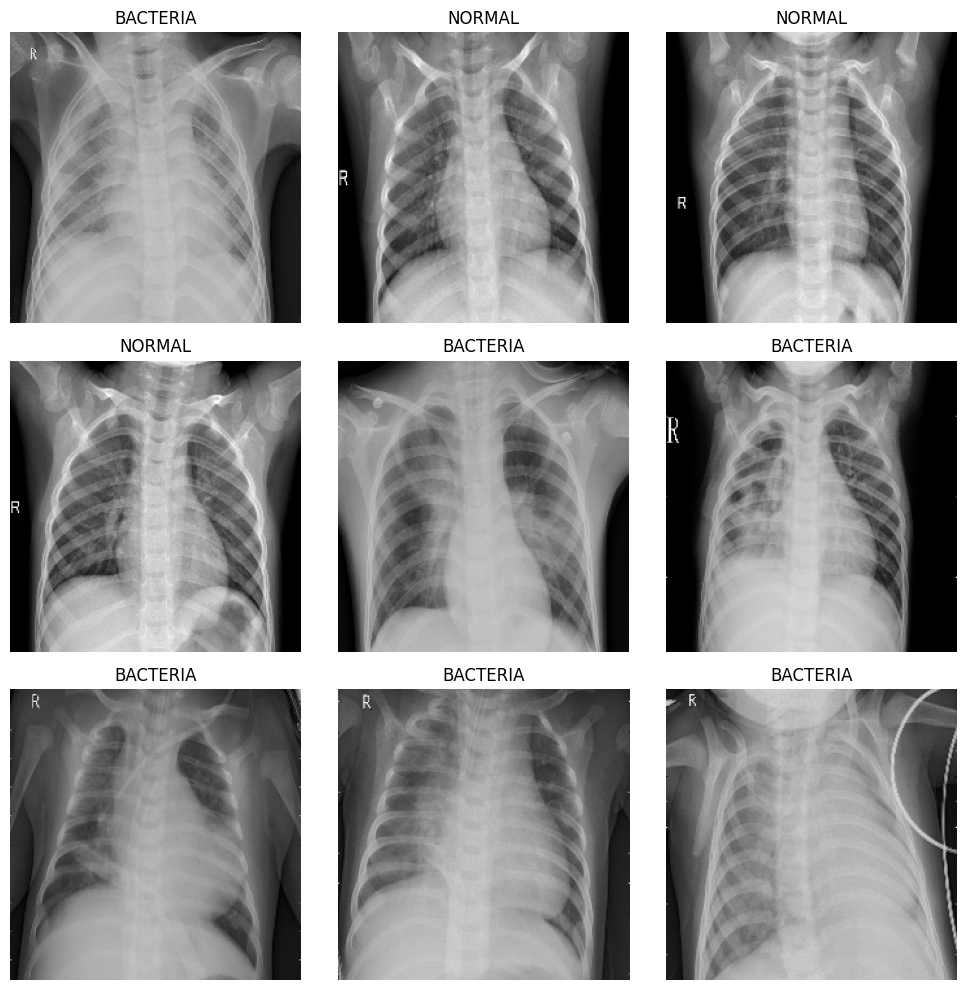

In [64]:
plt.figure(figsize=(10,10))

for images, labels in train_ds.take(1):

    for i in range(9):

        plt.subplot(3,3,i+1)

        plt.imshow(images[i].numpy())

        plt.title(class_names[int(labels[i].numpy())])

        plt.axis("off")

plt.tight_layout()
plt.show()

Cell 13: Dataset Summary

In [65]:
print("Train Batches      :", tf.data.experimental.cardinality(train_ds).numpy())
print("Validation Batches :", tf.data.experimental.cardinality(val_ds).numpy())
print("Test Batches       :", tf.data.experimental.cardinality(test_ds).numpy())

Train Batches      : 129
Validation Batches : 28
Test Batches       : 28


In [66]:
for images, labels in train_ds.take(1):
    print("Image Batch Shape :", images.shape)
    print("Label Shape       :", labels.shape)

Image Batch Shape : (32, 224, 224, 3)
Label Shape       : (32,)


In [67]:
print("Class Names :", class_names)

print("Training Samples :", 4099)
print("Validation Samples :", 878)
print("Test Samples :", 879)

Class Names : ['BACTERIA', 'NORMAL', 'VIRUS']
Training Samples : 4099
Validation Samples : 878
Test Samples : 879
